strategy
Создать систему для интернет-магазина, которая рассчитывает налог на товары в зависимости от страны покупателя.
Создать заказ из 3 товаров (ноутбук, мышь, клавиатура). Рассчитать налог для США, ЕС и страны без налога. Показать разницу в итоговой цене.

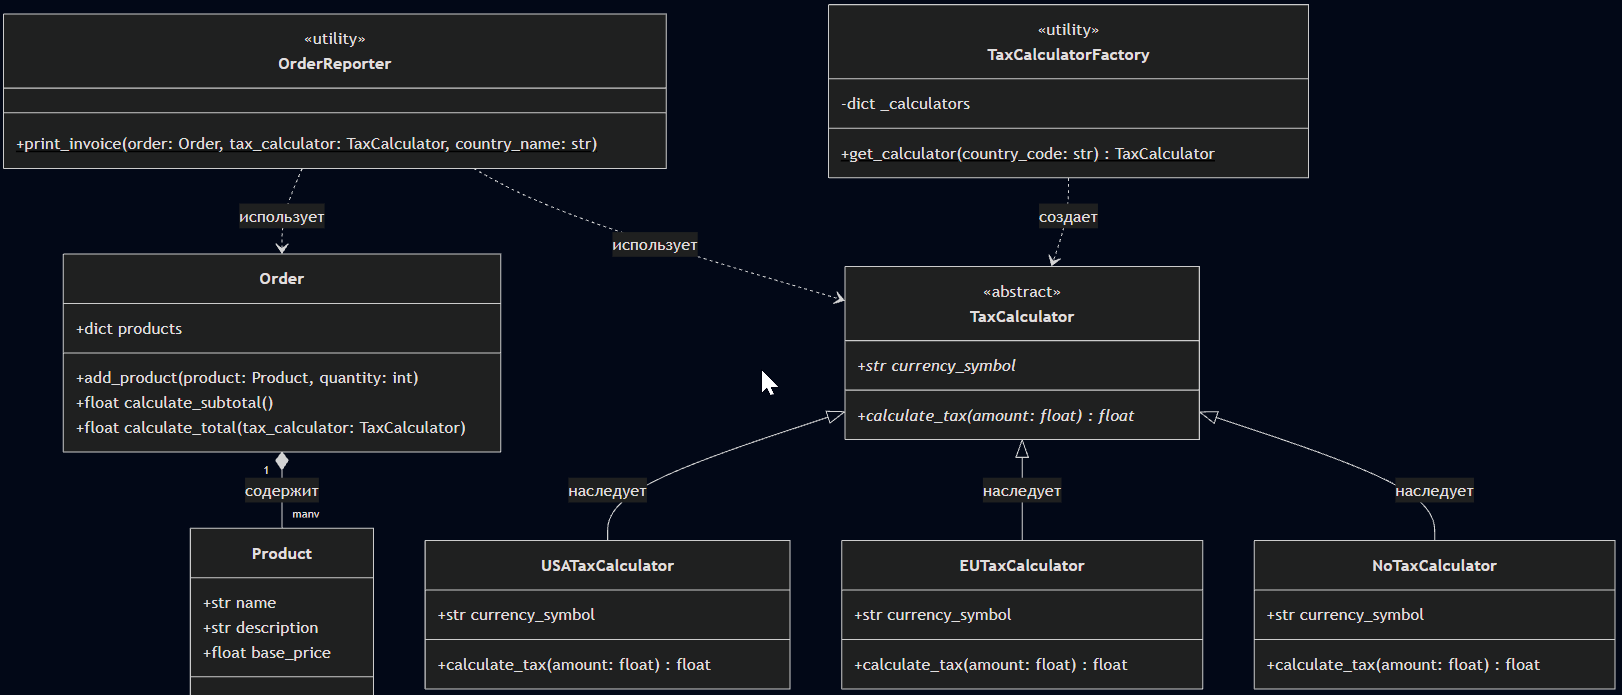
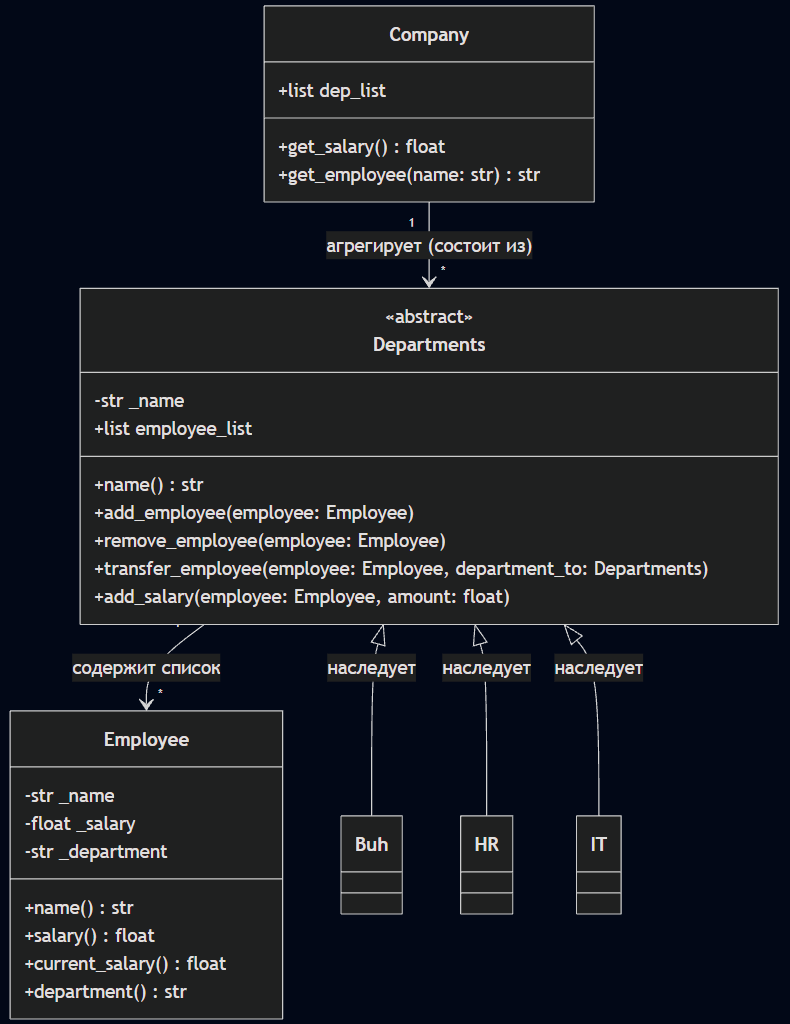

In [ ]:
from abc import ABC, abstractmethod

class TaxCalculator(ABC):
    @property
    @abstractmethod
    def currency_symbol(self) -> str:
        """Возвращает символ валюты для данной страны"""
        pass

    @abstractmethod
    def calculate_tax(self, amount: float) -> float:
        """Вычисляет сумму налога для переданной стоимости"""
        pass

class USATaxCalculator(TaxCalculator):
    # возвращаем символ для чека
    @property
    def currency_symbol(self) -> str:
        return "$"

    def calculate_tax(self, amount: float) -> float:
        return amount * 0.1

class EUTaxCalculator(TaxCalculator):
    @property
    def currency_symbol(self) -> str:
        return "€"

    def calculate_tax(self, amount: float) -> float:
        return amount * 0.2

class NoTaxCalculator(TaxCalculator):
    @property
    def currency_symbol(self) -> str:
        return "у.е."

    def calculate_tax(self, amount: float) -> float:
        return amount * 0.0

class Product:
    def __init__(self, name: str, description: str, base_price: float):
        self.name = name
        self.description = description
        self.base_price = base_price

class Order:
    def __init__(self):
        # ключ это объект клсса Product, значение - количество в заказе
        self.products = {}

    def add_product(self, product: Product, quantity: int = 1):
        # прибавляем quantity в количество при вызове функции, по умолчанию 1 штука(если не указали количество)
        if product in self.products:
            self.products[product] += quantity
        else:
            self.products[product] = quantity

    def calculate_subtotal(self) -> float:
        total = 0.0
        for product, quantity in self.products.items():
            # в словаре перебираем по ключ(объект),значение(количество) каждый объект
            # и суммируем для учета суммы без налога умножением количества на цену
            total += quantity * product.base_price
        return total

    def calculate_total(self, tax_calculator: TaxCalculator) -> float:
        # берем сумму без налога
        subtotal = self.calculate_subtotal()
        # считаем только налог по сумме
        tax = tax_calculator.calculate_tax(subtotal)
        return tax + subtotal


class TaxCalculatorFactory:
    # словарь сопоставляет код страны с соответствующим классом
    _calculators = {
        "USA": USATaxCalculator,
        "EU": EUTaxCalculator,
        "NONE": NoTaxCalculator
    }

    @staticmethod
    def get_calculator(country_code: str) -> TaxCalculator:
        # Получаем класс из словаря (по умолчанию NoTaxCalculator, если код не найден)
        calculator_class = TaxCalculatorFactory._calculators.get(country_code, NoTaxCalculator)

        # Создаем и возвращаем объект этого класса
        return calculator_class()

class OrderReporter:
    @staticmethod
    def print_invoice(order: Order, tax_calculator: TaxCalculator, country_name: str):
        subtotal = order.calculate_subtotal()
        tax = tax_calculator.calculate_tax(subtotal)
        total = order.calculate_total(tax_calculator)

        # Получаем символ валюты напрямую из калькулятора!
        symbol = tax_calculator.currency_symbol

        print(f"--- Отчет для {country_name} ---")
        print(f"Стоимость товаров: {subtotal:.2f} {symbol}")
        print(f"Налог: {tax:.2f} {symbol}")
        print(f"Итоговая цена: {total:.2f} {symbol}\n")

# Создаём объекты товаров для словаря
laptop = Product("Ноутбук", "Игровой ноутбук", 120000.0)
mouse = Product("Мышь", "Беспроводная мышь", 3500.0)
keyboard = Product("Клавиатура", "Механическая клавиатура", 6500.0)

# Создаем заказ и добавляем товары
my_order = Order()
my_order.add_product(laptop, 1)
my_order.add_product(mouse, 1)
my_order.add_product(keyboard, 1)

# Запрашиваем калькуляторы из словаря сопоставления и выводим отчеты
usa_calc = TaxCalculatorFactory.get_calculator("USA")
eu_calc = TaxCalculatorFactory.get_calculator("EU")
none_calc = TaxCalculatorFactory.get_calculator("NONE")

# Вызываем репортер для вывода чека и передаем ему объекты что бы показать разницу в итоговой цене
OrderReporter.print_invoice(my_order, usa_calc, "США (USA)")
OrderReporter.print_invoice(my_order, eu_calc, "Европейский Союз (EU)")
OrderReporter.print_invoice(my_order, none_calc, "Страна без налога")


Создать компанию с 3 отделами, в каждом по 2-3 сотрудника. Вывести общую зарплату компании и найти конкретного сотрудника

![image.png](attachment:6c2826fd-f5d1-4a7f-b023-ea5899c20b3b.png)

In [1]:
from abc import ABC, abstractmethod


class Employee:
    def __init__(self, name: str, salary: float, department: str):
        self._name = name
        self._salary = salary
        self._department = department

    def name(self) -> str:
        return self._name

    def salary(self) -> float:
        return self._salary

# для изменения зарплаты
    @property
    def current_salary(self) -> float:
        return self._salary

    @current_salary.setter
    def current_salary(self, amount: float):
        self._salary = amount

    def department(self) -> str:
        return self._department


class Departments(ABC):
    def __init__(self, name: str):
        self._name = name
        self.employee_list = []  # добавляем сотрудников в список для поиска

    def name(self) -> str:
        return self._name

    def add_employee(self, employee: Employee):
        #поиск по имени в списке
        if not any(emp.name() == employee.name() for emp in self.employee_list):
            self.employee_list.append(employee)
            print(f"Сотрудник {employee.name()} добавлен в отдел {self._name}.")
        else:
            print(f"Сотрудник {employee.name()} уже числится в отделе!")

    def remove_employee(self, employee: Employee):
        for emp in self.employee_list:
            if emp.name() == employee.name():
                self.employee_list.remove(emp)
                print(f"Сотрудник {employee.name()} удален из отдела {self._name}.")
                return
        print(f"Сотрудник {employee.name()} не работает в отделе!")

    def transfer_employee(self, employee: Employee, department_to: "Departments"):
        # проверяем тут ли сотрудник
        if any(emp.name() == employee.name() for emp in self.employee_list):
            self.remove_employee(employee)
            department_to.add_employee(employee)
            employee._department = department_to.name()  # обновляем отдел у сотрудника
        else:
            print(f"Сотрудник {employee.name()} не работает в отделе {self._name}!")

    def add_salary(self, employee: Employee, amount: float):
        for emp in self.employee_list:
            if emp.name() == employee.name():
                emp.current_salary += amount
                print(f"Зарплата {employee.name()} успешно увеличена на {amount}.")
                return
        print(f"Сотрудник {employee.name()} не работает в отделе!")

# для создания объектов конкретных отделов
class Buh(Departments):
    pass


class HR(Departments):
    pass


class IT(Departments):
    pass


class Company:
    def __init__(self, departments: list):
        self.dep_list = departments

    def get_salary(self) -> float:
        sum_emp = 0
        seen_names = set()  # используем множество для проверки уникальности
        for dep in self.dep_list:
            for emp in dep.employee_list:
                if emp.name() not in seen_names:
                    sum_emp += emp.salary()
                    seen_names.add(emp.name())
        return sum_emp

    def get_employee(self, name: str) -> str:
        for dep in self.dep_list:
            for emp in dep.employee_list:
                if emp.name() == name:
                    return f"Сотрудник {name} найден в отделе {dep.name()}"
        return f"Сотрудник {name} не найден"


# создаем отделы
buh_dep = Buh("Бухгалтерия")
hr_dep = HR("Кадры")
it_dep = IT("Разработка")

# создаем сотрудников
emp1 = Employee("Иван", 50000, "Разработка")
emp2 = Employee("Анна", 60000, "Бухгалтерия")
emp3 = Employee("Петр", 70000, "Разработка")

# создаем компанию и передаем ей наши отделы
my_company = Company([buh_dep, hr_dep, it_dep])

print("***Проверка добавления сотрудников")
it_dep.add_employee(emp1)
it_dep.add_employee(emp3)
buh_dep.add_employee(emp2)
# проверка на дубликаты
it_dep.add_employee(emp1)

print("\n***Проверка расчета общей зарплаты")
print(f"Общий зарплатный фонд: {my_company.get_salary()}")

print("\n***Проверка изменения зарплаты")
it_dep.add_salary(emp1, 15000) # Увеличиваем ЗП Ивану
# пытаемся поднять зп сотруднику, которого нет в Бухгалтерии
buh_dep.add_salary(emp3, 10000)

print("\n***Проверка перевода в другой отдел")
# переводим Петра из IT в HR
it_dep.transfer_employee(emp3, hr_dep)
# Пытаемся снова перевести Ивана туда, где он уже есть (после перевода, например)
# Или проверяем, что Петр теперь в новом отделе:
print(my_company.get_employee("Петр"))

print("\n***Проверка удаления сотрудника")
buh_dep.remove_employee(emp2)
# Попытка удалить Ивана из бухгалтерии (где его нет):
buh_dep.remove_employee(emp1)

print("\n***Финальная проверка фонда после изменений")
# Иван 50к+15к=65к + Петр 70к = 135к (Анна удалена)
print(f"Новый общий зарплатный фонд: {my_company.get_salary()}")

***Проверка добавления сотрудников
Сотрудник Иван добавлен в отдел Разработка.
Сотрудник Петр добавлен в отдел Разработка.
Сотрудник Анна добавлен в отдел Бухгалтерия.
Сотрудник Иван уже числится в отделе!

***Проверка расчета общей зарплаты
Общий зарплатный фонд: 180000

***Проверка изменения зарплаты
Зарплата Иван успешно увеличена на 15000.
Сотрудник Петр не работает в отделе!

***Проверка перевода в другой отдел
Сотрудник Петр удален из отдела Разработка.
Сотрудник Петр добавлен в отдел Кадры.
Сотрудник Петр найден в отделе Кадры

***Проверка удаления сотрудника
Сотрудник Анна удален из отдела Бухгалтерия.
Сотрудник Иван не работает в отделе!

***Финальная проверка фонда после изменений
Новый общий зарплатный фонд: 135000
